<a href="https://colab.research.google.com/github/japmanyakaur/early-disease-detection-in-crops/blob/main/crop_disease_TRAINING_v8_ENSEMBLE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crop Disease Detection — Ensemble + TTA (v8)



In [ ]:
import torch, random, numpy as np
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Using:", torch.cuda.get_device_name(0))
else:
    print("Go to Runtime > Change runtime type > select T4 GPU, then re-run this cell.")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


GPU available: True
Using: Tesla T4


## 1. Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

PROJECT_DIR = '/content/drive/MyDrive/crop-disease-model'
CKPT_DIR    = f'{PROJECT_DIR}/checkpoints'
DATA_CACHE  = f'{PROJECT_DIR}/data_cache'
for d in [PROJECT_DIR, CKPT_DIR, DATA_CACHE]:
    os.makedirs(d, exist_ok=True)
print("Everything persists under:", PROJECT_DIR)


Mounted at /content/drive
Everything persists under: /content/drive/MyDrive/crop-disease-model


## 2. Install dependencies

In [ ]:
!pip install -q kagglehub timm scikit-learn


## 3. Get the dataset (cached to Drive after first run)

In [ ]:
import shutil, glob, zipfile

DATA_DIR = "/content/data"
CACHE_ZIP = f"{DATA_CACHE}/tomato_grape_filtered_v3.zip"

def cache_looks_valid():
    return (os.path.isdir(f"{DATA_DIR}/train/tomato") and os.path.isdir(f"{DATA_DIR}/train/grape")
            and os.path.isdir(f"{DATA_DIR}/field_finetune/tomato") and os.path.isdir(f"{DATA_DIR}/field_finetune/grape"))

used_cache = False
if os.path.exists(CACHE_ZIP):
    print("Found cached filtered dataset on Drive - restoring (fast).")
    with zipfile.ZipFile(CACHE_ZIP) as zf:
        zf.extractall("/content")
    if cache_looks_valid():
        used_cache = True
        print("Restored to", DATA_DIR)
    else:
        print("Cached data is missing or old-format - rebuilding.")
        shutil.rmtree(DATA_DIR, ignore_errors=True)

if not used_cache:
    print("Downloading + filtering from scratch...")
    import kagglehub
    pv_path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
    train_dirs = glob.glob(pv_path + "/**/train", recursive=True)
    valid_dirs = glob.glob(pv_path + "/**/valid", recursive=True)
    if not train_dirs or not valid_dirs:
        raise RuntimeError("Could not find train/valid folders - inspect glob.glob(pv_path + '/**', recursive=True)")
    PV_TRAIN, PV_VALID = train_dirs[0], valid_dirs[0]

    def filter_crop_folders(src_dir, dst_dir, keywords):
        os.makedirs(dst_dir, exist_ok=True)
        kept = []
        for folder in sorted(glob.glob(f"{src_dir}/*")):
            name = os.path.basename(folder)
            if any(k in name for k in keywords):
                shutil.copytree(folder, f"{dst_dir}/{name}", dirs_exist_ok=True)
                kept.append(name)
        print(f"{dst_dir}: kept {len(kept)} classes")
        return kept

    for split, src in [("train", PV_TRAIN), ("valid", PV_VALID)]:
        filter_crop_folders(src, f"{DATA_DIR}/{split}/tomato", ("Tomato", "tomato"))
        filter_crop_folders(src, f"{DATA_DIR}/{split}/grape", ("Grape", "grape"))

    get_ipython().system("rm -rf /content/plantdoc")
    get_ipython().system("git clone --quiet --filter=blob:none --sparse https://github.com/pratikkayal/PlantDoc-Dataset.git /content/plantdoc")
    get_ipython().run_line_magic("cd", "/content/plantdoc")
    get_ipython().system('git sparse-checkout set "train/*Tomato*" "train/*tomato*" "train/*Grape*" "train/*grape*" "test/*Tomato*" "test/*tomato*" "test/*Grape*" "test/*grape*"')
    get_ipython().run_line_magic("cd", "/content")

    PLANTDOC_TO_PLANTVILLAGE = {
        "Tomato leaf bacterial spot":         "Tomato___Bacterial_spot",
        "Tomato Early blight leaf":           "Tomato___Early_blight",
        "Tomato leaf late blight":            "Tomato___Late_blight",
        "Tomato mold leaf":                   "Tomato___Leaf_Mold",
        "Tomato Septoria leaf spot":          "Tomato___Septoria_leaf_spot",
        "Tomato two spotted spider mites leaf": "Tomato___Spider_mites Two-spotted_spider_mite",
        "Tomato leaf yellow virus":           "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
        "Tomato leaf mosaic virus":           "Tomato___Tomato_mosaic_virus",
        "Tomato leaf":                        "Tomato___healthy",
        "grape leaf black rot":               "Grape___Black_rot",
        "grape leaf":                         "Grape___healthy",
    }

    PLANTDOC_SPLIT_TO_OURS = {"train": "field_finetune", "test": "field_eval"}
    for pd_split, our_split in PLANTDOC_SPLIT_TO_OURS.items():
        for pd_name, pv_name in PLANTDOC_TO_PLANTVILLAGE.items():
            src = f"/content/plantdoc/{pd_split}/{pd_name}"
            if os.path.isdir(src):
                crop_dir = "tomato" if pv_name.startswith("Tomato") else "grape"
                dst = f"{DATA_DIR}/{our_split}/{crop_dir}/{pv_name}"
                os.makedirs(dst, exist_ok=True)
                for f in os.listdir(src):
                    shutil.copy(os.path.join(src, f), dst)

    print("Caching filtered dataset to Drive...")
    shutil.make_archive(CACHE_ZIP.replace(".zip", ""), "zip", "/content", "data")
    print("Cached at", CACHE_ZIP)

FIELD_FINETUNE_DIR = f"{DATA_DIR}/field_finetune"
FIELD_EVAL_DIR = f"{DATA_DIR}/field_eval"
print("\nReady.")


Found cached filtered dataset on Drive - restoring (fast).
Restored to /content/data

Ready.


## 4. Browse the dataset — run this cell any time to see a fresh random batch

Re-run it as many times as you like; every run shows a different random sample.

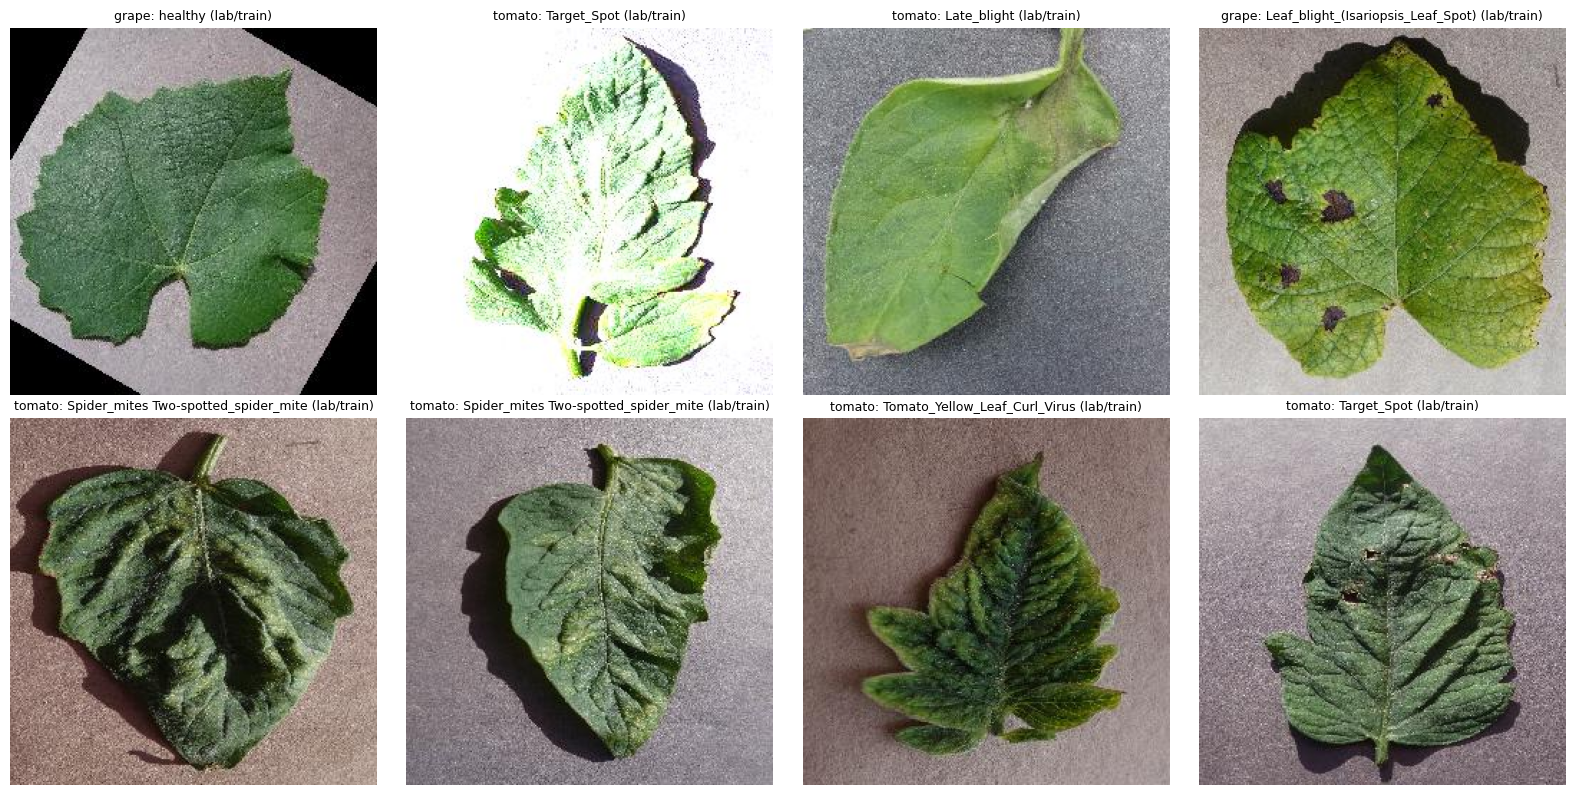

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image as PILImage
import random as _random

def browse_random_images(n=8):
    pool = []
    for crop_dir in ["tomato", "grape"]:
        for split_name, split_dir in [("lab/train", f"{DATA_DIR}/train/{crop_dir}"),
                                       ("real field", f"{FIELD_EVAL_DIR}/{crop_dir}")]:
            if not os.path.isdir(split_dir):
                continue
            for cls in os.listdir(split_dir):
                cls_dir = f"{split_dir}/{cls}"
                for fname in os.listdir(cls_dir):
                    pool.append((f"{cls_dir}/{fname}", f"{crop_dir}: {cls.split('___')[-1]} ({split_name})"))
    sample = _random.sample(pool, min(n, len(pool)))
    fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(4 * ((n + 1) // 2), 8))
    for ax, (path, label) in zip(axes.flat, sample):
        ax.imshow(PILImage.open(path)); ax.set_title(label, fontsize=9); ax.axis("off")
    for ax in axes.flat[len(sample):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

browse_random_images()


## 5. Training setup — bigger resolution, heavier field-realistic augmentation

224px -> 320px, and augmentation now includes rotation, perspective warp, and blur (simulating a farmer's phone camera at an angle) from the very first training stage, not just patched on later.

In [ ]:
import timm, torch, torch.nn as nn, json
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from collections import Counter

device = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 320
ENSEMBLE_ARCHS = ["mobilenetv3_large_100", "resnet50"]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.4),
    transforms.ColorJitter(0.3, 0.3, 0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tfm_flipped = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


## 6. Training function — same stable 3-stage design, parametrized by architecture

Called once per architecture per crop (4 total models: tomato-mobilenet, tomato-resnet, grape-mobilenet, grape-resnet).

In [ ]:
class FixedClassFolderDataset(torch.utils.data.Dataset):
    def __init__(self, root, classes, transform):
        self.samples, self.transform = [], transform
        if os.path.isdir(root):
            for cls in os.listdir(root):
                if cls not in classes:
                    continue
                cls_idx = classes.index(cls)
                cls_dir = os.path.join(root, cls)
                for fname in os.listdir(cls_dir):
                    self.samples.append((os.path.join(cls_dir, fname), cls_idx))
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, i):
        path, label = self.samples[i]
        return self.transform(PILImage.open(path).convert("RGB")), label


def train_crop_model(crop_dir, tag, arch_name, epochs_head=3, epochs_finetune=5, epochs_field_finetune=6):
    total_epochs = epochs_head + epochs_finetune + epochs_field_finetune
    ckpt_path = f"{CKPT_DIR}/{tag}_{arch_name}_latest.pt"
    log_path  = f"{CKPT_DIR}/{tag}_{arch_name}_log.csv"

    train_ds = datasets.ImageFolder(f"{DATA_DIR}/train/{crop_dir}", train_tfm)
    val_ds   = datasets.ImageFolder(f"{DATA_DIR}/valid/{crop_dir}", eval_tfm)
    classes = train_ds.classes

    expected_prefix = "Tomato___" if crop_dir == "tomato" else "Grape___"
    assert all(c.startswith(expected_prefix) for c in classes), (
        f"[{tag}] SANITY CHECK FAILED: crop_dir={crop_dir!r} but classes are {classes}"
    )
    print(f"[{tag}/{arch_name}] {len(classes)} classes: {classes}")

    train_dl = DataLoader(train_ds, batch_size=24, shuffle=True, num_workers=2)
    val_dl   = DataLoader(val_ds, batch_size=24, num_workers=2)

    field_ds = FixedClassFolderDataset(f"{FIELD_FINETUNE_DIR}/{crop_dir}", classes, train_tfm)
    field_dl = DataLoader(field_ds, batch_size=16, shuffle=True, num_workers=2) if len(field_ds) > 0 else None

    model = timm.create_model(arch_name, pretrained=True, num_classes=len(classes)).to(device)

    start_epoch = 0
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device)
        if ckpt.get("arch_name") == arch_name and ckpt.get("crop_dir") == crop_dir:
            model.load_state_dict(ckpt["model_state"])
            start_epoch = ckpt["epoch"] + 1
            print(f"[{tag}/{arch_name}] Resuming from epoch {start_epoch}/{total_epochs}")
        else:
            print(f"[{tag}/{arch_name}] Checkpoint mismatch - starting fresh.")

    if start_epoch >= total_epochs:
        print(f"[{tag}/{arch_name}] Already fully trained ({total_epochs} epochs).")
        return model, classes

    if not os.path.exists(log_path):
        with open(log_path, "w") as f:
            f.write("epoch,stage,train_loss,train_acc,lab_val_acc\n")

    loss_fn = nn.CrossEntropyLoss()
    field_start = epochs_head + epochs_finetune

    for epoch in range(start_epoch, total_epochs):
        if epoch < epochs_head:
            stage = "head"
            for p in model.parameters(): p.requires_grad = False
            for p in model.get_classifier().parameters(): p.requires_grad = True
            opt = torch.optim.Adam(model.get_classifier().parameters(), lr=1e-3)
            epoch_dl = train_dl
        elif epoch < field_start:
            stage = "finetune"
            for p in model.parameters(): p.requires_grad = True
            opt = torch.optim.Adam(model.parameters(), lr=1e-5)
            epoch_dl = train_dl
        else:
            stage = "field_finetune"
            for p in model.parameters(): p.requires_grad = False
            for p in model.get_classifier().parameters(): p.requires_grad = True
            opt = torch.optim.Adam(model.get_classifier().parameters(), lr=1e-3)
            if field_dl is None:
                print(f"[{tag}/{arch_name}] no field data - skipping epoch {epoch+1}.")
                torch.save({"model_state": model.state_dict(), "epoch": epoch, "arch_name": arch_name,
                            "crop_dir": crop_dir, "classes": classes}, ckpt_path)
                continue
            epoch_dl = field_dl

        model.train()
        total, correct, running_loss = 0, 0, 0.0
        for imgs, labels in epoch_dl:
            imgs, labels = imgs.to(device), labels.to(device)
            opt.zero_grad()
            out = model(imgs)
            loss = loss_fn(out, labels)
            loss.backward()
            opt.step()
            running_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total += imgs.size(0)
        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        vtotal, vcorrect = 0, 0
        with torch.no_grad():
            for imgs, labels in val_dl:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                vcorrect += (out.argmax(1) == labels).sum().item()
                vtotal += imgs.size(0)
        val_acc = vcorrect / vtotal

        print(f"[{tag}/{arch_name}] epoch {epoch+1}/{total_epochs} ({stage})  train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  lab_val_acc={val_acc:.4f}")
        with open(log_path, "a") as f:
            f.write(f"{epoch},{stage},{train_loss:.4f},{train_acc:.4f},{val_acc:.4f}\n")
        torch.save({"model_state": model.state_dict(), "epoch": epoch, "arch_name": arch_name,
                    "crop_dir": crop_dir, "classes": classes}, ckpt_path)

    return model, classes


## 7. Train all 4 models (2 crops x 2 architectures) — this is the long-running cell

In [ ]:
tomato_models = {}
for arch in ENSEMBLE_ARCHS:
    model, tomato_classes = train_crop_model("tomato", tag="tomato", arch_name=arch)
    tomato_models[arch] = model


[tomato/mobilenetv3_large_100] 10 classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


model.safetensors: reconstructing file:   0%|          |  0.00B / 22.1MB            

model.safetensors: downloading bytes:           |  0.00B            

[tomato/mobilenetv3_large_100] epoch 1/14 (head)  train_loss=0.9722  train_acc=0.6819  lab_val_acc=0.8410
[tomato/mobilenetv3_large_100] epoch 2/14 (head)  train_loss=0.3881  train_acc=0.8767  lab_val_acc=0.8986
[tomato/mobilenetv3_large_100] epoch 3/14 (head)  train_loss=0.2948  train_acc=0.9055  lab_val_acc=0.9082
[tomato/mobilenetv3_large_100] epoch 4/14 (finetune)  train_loss=0.2099  train_acc=0.9319  lab_val_acc=0.9511
[tomato/mobilenetv3_large_100] epoch 5/14 (finetune)  train_loss=0.1464  train_acc=0.9516  lab_val_acc=0.9597
[tomato/mobilenetv3_large_100] epoch 6/14 (finetune)  train_loss=0.1116  train_acc=0.9617  lab_val_acc=0.9804
[tomato/mobilenetv3_large_100] epoch 7/14 (finetune)  train_loss=0.0791  train_acc=0.9736  lab_val_acc=0.9812
[tomato/mobilenetv3_large_100] epoch 8/14 (finetune)  train_loss=0.0628  train_acc=0.9793  lab_val_acc=0.9858
[tomato/mobilenetv3_large_100] epoch 9/14 (field_finetune)  train_loss=3.6395  train_acc=0.2718  lab_val_acc=0.7402
[tomato/mobilene

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

[tomato/resnet50] epoch 1/14 (head)  train_loss=1.5093  train_acc=0.6130  lab_val_acc=0.7267
[tomato/resnet50] epoch 2/14 (head)  train_loss=0.9323  train_acc=0.7650  lab_val_acc=0.8026
[tomato/resnet50] epoch 3/14 (head)  train_loss=0.7311  train_acc=0.8099  lab_val_acc=0.8270
[tomato/resnet50] epoch 4/14 (finetune)  train_loss=0.4919  train_acc=0.8633  lab_val_acc=0.8977
[tomato/resnet50] epoch 5/14 (finetune)  train_loss=0.3533  train_acc=0.8959  lab_val_acc=0.9204
[tomato/resnet50] epoch 6/14 (finetune)  train_loss=0.2782  train_acc=0.9145  lab_val_acc=0.9357
[tomato/resnet50] epoch 7/14 (finetune)  train_loss=0.2305  train_acc=0.9298  lab_val_acc=0.9507
[tomato/resnet50] epoch 8/14 (finetune)  train_loss=0.1957  train_acc=0.9393  lab_val_acc=0.9607
[tomato/resnet50] epoch 9/14 (field_finetune)  train_loss=2.5524  train_acc=0.2674  lab_val_acc=0.6696
[tomato/resnet50] epoch 10/14 (field_finetune)  train_loss=2.3318  train_acc=0.2806  lab_val_acc=0.6718
[tomato/resnet50] epoch 11/14

In [ ]:
grape_models = {}
for arch in ENSEMBLE_ARCHS:
    model, grape_classes = train_crop_model("grape", tag="grape", arch_name=arch)
    grape_models[arch] = model


[grape/mobilenetv3_large_100] 4 classes: ['Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy']
[grape/mobilenetv3_large_100] epoch 1/14 (head)  train_loss=1.0029  train_acc=0.6624  lab_val_acc=0.8726
[grape/mobilenetv3_large_100] epoch 2/14 (head)  train_loss=0.2249  train_acc=0.9189  lab_val_acc=0.9657
[grape/mobilenetv3_large_100] epoch 3/14 (head)  train_loss=0.1335  train_acc=0.9489  lab_val_acc=0.9717
[grape/mobilenetv3_large_100] epoch 4/14 (finetune)  train_loss=0.0852  train_acc=0.9694  lab_val_acc=0.9878
[grape/mobilenetv3_large_100] epoch 5/14 (finetune)  train_loss=0.0513  train_acc=0.9823  lab_val_acc=0.9939
[grape/mobilenetv3_large_100] epoch 6/14 (finetune)  train_loss=0.0435  train_acc=0.9835  lab_val_acc=0.9950
[grape/mobilenetv3_large_100] epoch 7/14 (finetune)  train_loss=0.0274  train_acc=0.9903  lab_val_acc=0.9978
[grape/mobilenetv3_large_100] epoch 8/14 (finetune)  train_loss=0.0191  train_acc=0.9938 

## 8. Ensemble + TTA prediction and evaluation

Averages predictions across both architectures AND across original+flipped views of each image, then evaluates on the real field-photo test set.

In [ ]:
from sklearn.metrics import classification_report

def ensemble_tta_predict_tensor(models_dict, img_pil):
    all_probs = []
    for tfm in (eval_tfm, eval_tfm_flipped):
        tensor = tfm(img_pil).unsqueeze(0).to(device)
        for model in models_dict.values():
            model.eval()
            with torch.no_grad():
                all_probs.append(torch.softmax(model(tensor), dim=1))
    return torch.stack(all_probs).mean(dim=0)[0]

def evaluate_ensemble_on_field(models_dict, classes, crop_dir):
    field_path = f"{FIELD_EVAL_DIR}/{crop_dir}"
    if not os.path.isdir(field_path):
        print(f"No field-eval images for {crop_dir}")
        return
    all_preds, all_labels = [], []
    for cls in os.listdir(field_path):
        if cls not in classes:
            continue
        true_idx = classes.index(cls)
        for fname in os.listdir(f"{field_path}/{cls}"):
            img = PILImage.open(f"{field_path}/{cls}/{fname}").convert("RGB")
            probs = ensemble_tta_predict_tensor(models_dict, img)
            all_preds.append(probs.argmax().item())
            all_labels.append(true_idx)
    print(f"--- {crop_dir} field accuracy: ensemble ({'+'.join(models_dict.keys())}) + TTA ---")
    print(classification_report(all_labels, all_preds, labels=list(range(len(classes))),
                                 target_names=classes, zero_division=0))

evaluate_ensemble_on_field(tomato_models, tomato_classes, "tomato")
evaluate_ensemble_on_field(grape_models, grape_classes, "grape")


--- tomato field accuracy: ensemble (mobilenetv3_large_100+resnet50) + TTA ---
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.30      0.33      0.32         9
                        Tomato___Early_blight       0.50      0.44      0.47         9
                         Tomato___Late_blight       0.45      0.50      0.48        10
                           Tomato___Leaf_Mold       0.25      0.17      0.20         6
                  Tomato___Septoria_leaf_spot       0.50      0.82      0.62        11
Tomato___Spider_mites Two-spotted_spider_mite       0.00      0.00      0.00         0
                         Tomato___Target_Spot       0.00      0.00      0.00         0
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.71      0.83      0.77         6
                 Tomato___Tomato_mosaic_virus       0.50      0.30      0.38        10
                             Tomato___healthy     

## 9. Live test: pick a random real field photo and watch it get classified

Run this cell as many times as you like — a fresh random photo each time, with its true label and the ensemble's prediction shown together. This is the cell to run in front of judges.

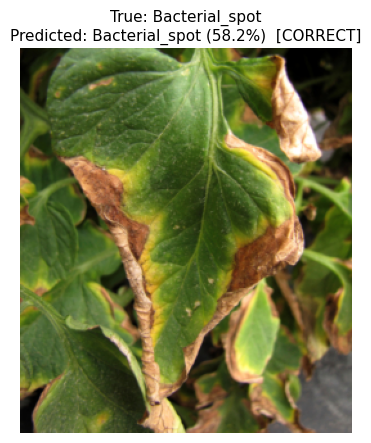

In [ ]:
def live_random_test(crop_dir, models_dict, classes):
    field_path = f"{FIELD_EVAL_DIR}/{crop_dir}"
    candidates = []
    for cls in os.listdir(field_path):
        for fname in os.listdir(f"{field_path}/{cls}"):
            candidates.append((f"{field_path}/{cls}/{fname}", cls))
    path, true_cls = _random.choice(candidates)
    img = PILImage.open(path).convert("RGB")

    probs = ensemble_tta_predict_tensor(models_dict, img)
    conf, idx = probs.max(0)
    pred_cls = classes[idx.item()]
    correct = "CORRECT" if pred_cls == true_cls else "WRONG"

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"True: {true_cls.split('___')[-1]}\nPredicted: {pred_cls.split('___')[-1]} ({conf*100:.1f}%)  [{correct}]",
               fontsize=11)
    plt.axis("off")
    plt.show()

live_random_test("tomato", tomato_models, tomato_classes)
# live_random_test("grape", grape_models, grape_classes)


## 10. Export final models

In [ ]:
for arch, model in tomato_models.items():
    torch.save(model.state_dict(), f"{PROJECT_DIR}/tomato_{arch}_final.pt")
for arch, model in grape_models.items():
    torch.save(model.state_dict(), f"{PROJECT_DIR}/grape_{arch}_final.pt")
json.dump({"classes": tomato_classes, "archs": ENSEMBLE_ARCHS, "img_size": IMG_SIZE}, open(f"{PROJECT_DIR}/tomato_meta.json", "w"))
json.dump({"classes": grape_classes, "archs": ENSEMBLE_ARCHS, "img_size": IMG_SIZE}, open(f"{PROJECT_DIR}/grape_meta.json", "w"))
print("Final ensemble models saved to", PROJECT_DIR)


Final ensemble models saved to /content/drive/MyDrive/crop-disease-model


## 11. predict() — for handoff and the demo notebook

In [ ]:
def predict(crop: str, image_path: str):
    models_dict, classes = (tomato_models, tomato_classes) if crop == "tomato" else (grape_models, grape_classes)
    img = PILImage.open(image_path).convert("RGB")
    probs = ensemble_tta_predict_tensor(models_dict, img)
    conf, idx = probs.max(0)
    label = classes[idx.item()].split("___")[-1]
    severity = "high" if conf > 0.85 else "medium" if conf > 0.6 else "low"
    return {"crop": crop, "disease": label, "confidence": round(conf.item(), 3), "severity": severity}
